In [12]:
import pandas as pd

# read the csv file with panda
df = pd.read_csv('/media/haupert/DATA/Sylvain/mes_projet_data/dB@Risoux/BirdNET_CombinedTable.csv')

# select the rows where the 'File' column contains "/media/dubois/LaCie/db@risoux/2019/MAGNETO_03"
df_filtered = df[df['File'].str.contains("/media/dubois/LaCie/db@risoux/2019/MAGNETO_03")]

# create a new column with the filename only (without the path)
df_filtered['Filename'] = df_filtered['File'].apply(lambda x: x.split('/')[-1])

# Find the species richness for each file
df_birdnet = df_filtered.groupby('Filename')['Scientific name'].nunique().reset_index()

# add a new column to the species_richness dataframe with the date of the recording, extracted from the filename (S4A03536_20190101_090000.wav) in datetime format
df_birdnet['date'] = pd.to_datetime(df_birdnet['Filename'].str[9:23], format='%Y%m%d_%H%M%S')

# set Date as DateTimeIndex
df_birdnet.set_index('date', inplace=True)

# replace the name of the column 'Scientific name' to 'Avian Species Richness Predicted over 1-minute Soundscape'
df_birdnet.rename(columns={'Scientific name': 'Avian Species Richness Predicted over 1-minute Soundscape'}, inplace=True)

df_birdnet

/tmp/ipykernel_193371/237569864.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Filename'] = df_filtered['File'].apply(lambda x: x.split('/')[-1])


,Filename,Avian Species Richness Predicted over 1-minute Soundscape
date,,
2019-01-01 09:00:00,S4A03536_20190101_090000.wav,2
2019-01-01 10:30:00,S4A03536_20190101_103000.wav,3
2019-01-01 10:45:00,S4A03536_20190101_104500.wav,2
2019-01-01 13:15:00,S4A03536_20190101_131500.wav,1
2019-01-01 13:30:00,S4A03536_20190101_133000.wav,2
...,...,...
2019-12-31 19:45:00,S4A03536_20191231_194500.wav,1
2019-12-31 20:30:00,S4A03536_20191231_203000.wav,1
2019-12-31 21:00:00,S4A03536_20191231_210000.wav,1


In [13]:
# create rows with missing dates in the index and fill them with 0 values for the 'Avian Species Richness Predicted over 1-minute Soundscape' column
# create a date range from the minimum to the maximum date in the index with a frequency of 15 minute
date_range = pd.date_range(start=df_birdnet.index.min(), end=df_birdnet.index.max(), freq='15T')
df_birdnet = df_birdnet.reindex(date_range, fill_value=0)

# rename the index to 'date'
df_birdnet.index.name = 'date'

df_birdnet

/tmp/ipykernel_193371/3543154369.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  date_range = pd.date_range(start=df_birdnet.index.min(), end=df_birdnet.index.max(), freq='15T')


,Filename,Avian Species Richness Predicted over 1-minute Soundscape
date,,
2019-01-01 09:00:00,S4A03536_20190101_090000.wav,2
2019-01-01 09:15:00,0,0
2019-01-01 09:30:00,0,0
2019-01-01 09:45:00,0,0
2019-01-01 10:00:00,0,0
...,...,...
2019-12-31 20:45:00,0,0
2019-12-31 21:00:00,S4A03536_20191231_210000.wav,1
2019-12-31 21:15:00,0,0


/media/haupert/DATA/Sylvain/mes_projets/scikit-maad/maad/util/visualization.py:1669: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_mean = df_mean.resample(time_resolution).mean()
/media/haupert/DATA/Sylvain/mes_projets/scikit-maad/maad/util/visualization.py:1670: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_std = df_mean.resample(time_resolution).std()


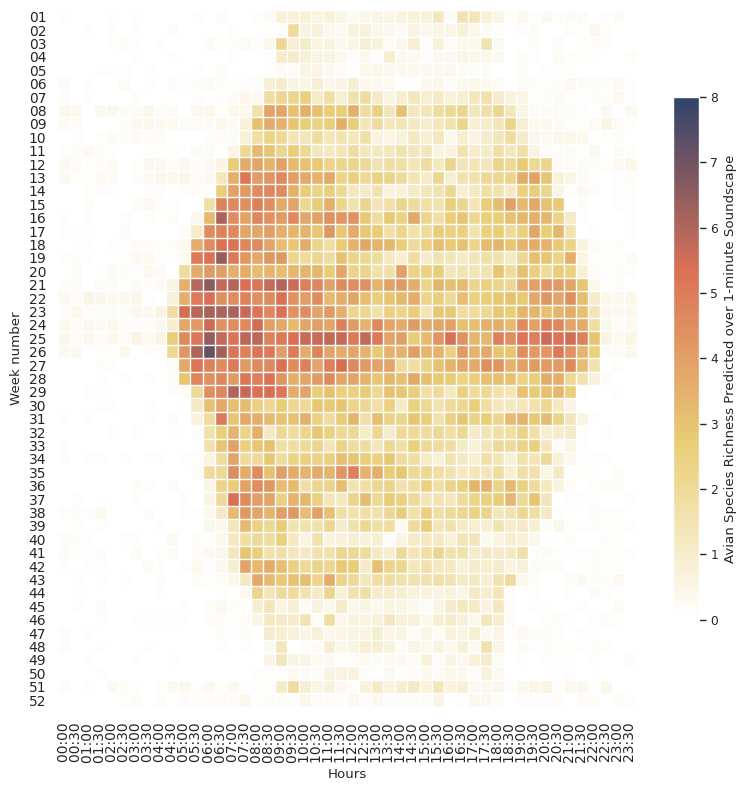

In [14]:
import numpy as np
import os

# maad
from maad.util import heatmap_by_date_and_time

from matplotlib.colors import LinearSegmentedColormap

# Create custom colormap: dark green -> yellow -> light green
colors = ["#FFFFFF", "#E9CE77", "#DB7156", "#31436B"]  # dark green, yellow, light green
custom_cmap = LinearSegmentedColormap.from_list('custom_green_yellow', colors)

# change the color map from blue to dark green passing through yellow and light green
_,_, fig, ax = heatmap_by_date_and_time(df_birdnet, 
                disp_column = 'Avian Species Richness Predicted over 1-minute Soundscape', 
                date_format = "%V",
                time_resolution='30T',
                start_hour='00:00',
                date_min_to_disp = 1,
                date_max_to_disp = 12,
                figsize=(8,8),
                vmin = np.percentile(df_birdnet['Avian Species Richness Predicted over 1-minute Soundscape'], 1),
                vmax = np.percentile(df_birdnet['Avian Species Richness Predicted over 1-minute Soundscape'], 99),
                # vmin = 1,
                # vmax = 8,
                cmap=custom_cmap,
                )

# save figure
fig.savefig(os.path.join('/media/haupert/DATA/Sylvain/mes_projets/07_nroi/nROI_publication_revision_v1.git/haupert_acoustic_indices_2025/results', 'figure_7_birdnet.png'), dpi=300)

In [10]:
# find in week 21 the highest value of the 'Avian Species Richness Predicted over 1-minute Soundscape' column and the corresponding date
df_birdnet_week21 = df_birdnet[df_birdnet.index.isocalendar().week == 21]
max_value = df_birdnet_week21['Avian Species Richness Predicted over 1-minute Soundscape'].max()
max_date = df_birdnet_week21[df_birdnet_week21['Avian Species Richness Predicted over 1-minute Soundscape'] == max_value].index[0]

print(f"The highest value of the 'Avian Species Richness Predicted over 1-minute Soundscape' column in week 21 is {max_value} and it corresponds to the date {max_date}.")

The highest value of the 'Avian Species Richness Predicted over 1-minute Soundscape' column in week 21 is 5 and it corresponds to the date 2019-05-22 09:45:00.


In [11]:
# get the predicted species using df based on the date of the maximum value
predicted_species = df_filtered[df_filtered['File'].str.contains(max_date.strftime('%Y%m%d_%H%M%S'))]['Scientific name'].unique()

print(f"The predicted species for the date {max_date} are: {predicted_species}.")

The predicted species for the date 2019-05-22 09:45:00 are: ['Fringilla coelebs' 'Turdus philomelos' 'Erithacus rubecula'
 'Scolopax rusticola' 'Turdus viscivorus'].
